In [3]:
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'experiments' / 'utils').exists()), None)
if project_root is None:
    raise RuntimeError('Project root not found from current working directory.')
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from experiments.utils.confidence_intervals import round_metrics_with_ci_table, summarize_metrics_with_ci

In [4]:
fp32_path = "../../../full_precision/forgeting/experiments"


# Attack forg ep

In [5]:
expath = '../attack_forg_ep'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_forg_ep.parquet'))

# attach also baseline
df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_forg_ep/attack_forg_ep.parquet")) [['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
       '7b_ep0', '7b_ep0_em', '7b_ep0_bleu', '7b_ep0_meteor',
       '7b_ep0_rougeL', '7b_ep1', '7b_ep1_em', '7b_ep1_bleu',
       '7b_ep1_meteor', '7b_ep1_rougeL', '7b_ep2', '7b_ep2_em',
       '7b_ep2_bleu', '7b_ep2_meteor', '7b_ep2_rougeL', '7b_ep3',
       '7b_ep3_em', '7b_ep3_bleu', '7b_ep3_meteor', '7b_ep3_rougeL']]

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')


### LoRA

In [6]:
merged_df.columns

Index(['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
       '7b_lo_ep1', '7b_lo_ep1_em', '7b_lo_ep1_bleu', '7b_lo_ep1_meteor',
       '7b_lo_ep1_rougeL', '7b_lo_ep2', '7b_lo_ep2_em', '7b_lo_ep2_bleu',
       '7b_lo_ep2_meteor', '7b_lo_ep2_rougeL', '7b_lo_ep3', '7b_lo_ep3_em',
       '7b_lo_ep3_bleu', '7b_lo_ep3_meteor', '7b_lo_ep3_rougeL', '7b_ep0',
       '7b_ep0_em', '7b_ep0_bleu', '7b_ep0_meteor', '7b_ep0_rougeL', '7b_ep1',
       '7b_ep1_em', '7b_ep1_bleu', '7b_ep1_meteor', '7b_ep1_rougeL', '7b_ep2',
       '7b_ep2_em', '7b_ep2_bleu', '7b_ep2_meteor', '7b_ep2_rougeL', '7b_ep3',
       '7b_ep3_em', '7b_ep3_bleu', '7b_ep3_meteor', '7b_ep3_rougeL'],
      dtype='object')

In [7]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep1', 'ep2', 'ep3']

lo_means_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'7b_lo_{ep}_{metric}',
)
lo_means = lo_means_ci[metrics].copy()
lo_means_ci = round_metrics_with_ci_table(lo_means_ci, decimals=3)
lo_means_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep1,0.226,"[0.201, 0.253]",57.175,"[54.974, 59.293]",0.648,"[0.629, 0.668]",0.616,"[0.596, 0.637]"
ep2,0.224,"[0.199, 0.251]",56.868,"[54.671, 59.061]",0.646,"[0.627, 0.666]",0.615,"[0.594, 0.636]"
ep3,0.218,"[0.194, 0.245]",56.948,"[54.729, 59.121]",0.647,"[0.627, 0.667]",0.616,"[0.595, 0.636]"


In [8]:
# baseline_means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

base_means_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'7b_{ep}_{metric}',
)
base_means = base_means_ci[metrics].copy()
base_means_ci = round_metrics_with_ci_table(base_means_ci, decimals=3)
base_means_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.395,"[0.365, 0.426]",66.351,"[64.163, 68.524]",0.720,"[0.7, 0.74]",0.694,"[0.674, 0.715]"
ep1,0.015,"[0.009, 0.025]",38.141,"[36.406, 39.915]",0.525,"[0.507, 0.542]",0.483,"[0.465, 0.502]"
ep2,0.110,"[0.092, 0.131]",46.088,"[44.059, 48.118]",0.566,"[0.548, 0.585]",0.527,"[0.508, 0.547]"
ep3,0.116,"[0.098, 0.137]",46.953,"[44.955, 48.982]",0.572,"[0.554, 0.59]",0.534,"[0.514, 0.553]"


## Visuals


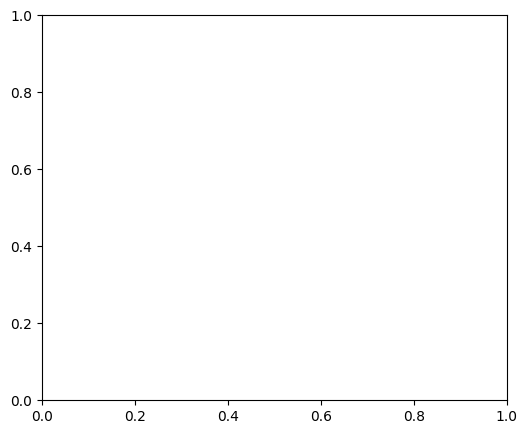

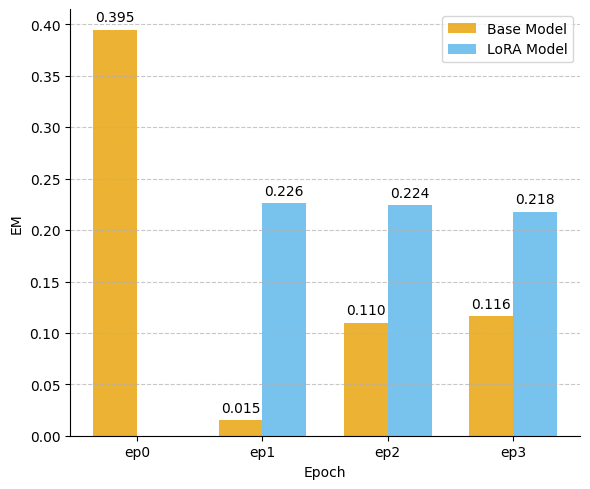

In [9]:
from matplotlib.lines import Line2D
from cycler import cycler

import matplotlib.pyplot as plt
import numpy as np

# Set up the plot
fig, ax = plt.subplots(figsize=(6, 5))

# EM data for both models
base_em = [base_means.loc[ep, 'em'] for ep in eps]
lo_em = [lo_means.loc[ep, 'em'] for ep in ['ep1', 'ep2', 'ep3']]  # lo_means doesn't have ep0

# Bar positions and width
x_pos = np.arange(len(eps))
bar_width = 0.35

# Plot base model EM
base_bars = ax.bar(x_pos - bar_width/2, base_em, bar_width, 
                   label='Base Model', color='#E69F00', alpha=0.8)

# Plot LoRA model EM (starting from ep1)
lo_bars = ax.bar(x_pos[1:] + bar_width/2, lo_em, bar_width, 
                 label='LoRA Model', color='#56B4E9', alpha=0.8)

# Customize the plot
ax.set_xlabel('Epoch')
ax.set_ylabel('EM')
# ax.set_title('Exact Match Performance: Base vs LoRA Model')
ax.set_xticks(x_pos)
ax.set_xticklabels(eps)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bars in [base_bars, lo_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)
        
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hide all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()

fig.savefig('./lo_attack_forg_ep.pdf', format='pdf')

# Attack forg plen

In [10]:
expath = '../attack_forg_plen'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_forg_plen.parquet'))

# attach also fp32
df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_forg_plen/attack_forg_plen.parquet"))

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

In [11]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_fp32_absolute_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'7b_{eps[1]}_{plen}_{metric}',
)
plen_fp32_absolute = plen_fp32_absolute_ci[metrics].copy()
plen_fp32_absolute_ci = round_metrics_with_ci_table(plen_fp32_absolute_ci, decimals=3)
plen_fp32_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.116,"[0.098, 0.137]",46.953,"[44.962, 48.926]",0.572,"[0.554, 0.591]",0.534,"[0.515, 0.553]"
p150,0.150,"[0.129, 0.173]",52.447,"[50.376, 54.488]",0.616,"[0.597, 0.634]",0.582,"[0.562, 0.602]"
p200,0.171,"[0.149, 0.196]",54.608,"[52.502, 56.691]",0.631,"[0.612, 0.65]",0.599,"[0.58, 0.619]"
p250,0.178,"[0.156, 0.203]",56.037,"[53.912, 58.079]",0.642,"[0.624, 0.661]",0.613,"[0.593, 0.632]"


In [12]:
# With the baseline

plen_fp32_ep0_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'7b_{eps[0]}_{plen}_{metric}',
)
plen_fp32_ep0 = plen_fp32_ep0_ci[metrics].copy()
plen_fp32_ep0_ci = round_metrics_with_ci_table(plen_fp32_ep0_ci, decimals=3)
plen_fp32_baseline = plen_fp32_absolute.subtract(plen_fp32_ep0)
plen_fp32_baseline

,em,bleu,meteor,rougeL
p100,-0.279,-19.397761,-0.147621,-0.160333
p150,-0.302,-18.540148,-0.141045,-0.152364
p200,-0.314,-18.462455,-0.140814,-0.154554
p250,-0.320,-18.194811,-0.139404,-0.150974


In [14]:
# merged_df.columns
pd.DataFrame(mean_data)

NameError: name 'mean_data' is not defined

In [15]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

lo_means_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'7b_lo_{eps[1]}_{plen}_{metric}',
)
lo_means = lo_means_ci[metrics].copy()
lo_means_ci = round_metrics_with_ci_table(lo_means_ci, decimals=3)
lo_means_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.218,"[0.194, 0.245]",56.948,"[54.754, 59.096]",0.647,"[0.628, 0.668]",0.616,"[0.595, 0.636]"
p150,0.287,"[0.26, 0.316]",61.168,"[58.987, 63.349]",0.680,"[0.661, 0.699]",0.653,"[0.632, 0.673]"
p200,0.307,"[0.279, 0.336]",63.444,"[61.254, 65.565]",0.698,"[0.679, 0.717]",0.673,"[0.653, 0.694]"
p250,0.328,"[0.3, 0.358]",64.849,"[62.66, 67.017]",0.708,"[0.689, 0.727]",0.685,"[0.665, 0.705]"


In [16]:
# baseline_means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

base_means_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'7b_{eps[1]}_{plen}_{metric}',
)
base_means = base_means_ci[metrics].copy()
base_means_ci = round_metrics_with_ci_table(base_means_ci, decimals=3)
base_means_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.116,"[0.098, 0.137]",46.953,"[44.962, 48.926]",0.572,"[0.554, 0.591]",0.534,"[0.515, 0.553]"
p150,0.150,"[0.129, 0.173]",52.447,"[50.376, 54.488]",0.616,"[0.597, 0.634]",0.582,"[0.562, 0.602]"
p200,0.171,"[0.149, 0.196]",54.608,"[52.502, 56.691]",0.631,"[0.612, 0.65]",0.599,"[0.58, 0.619]"
p250,0.178,"[0.156, 0.203]",56.037,"[53.912, 58.079]",0.642,"[0.624, 0.661]",0.613,"[0.593, 0.632]"


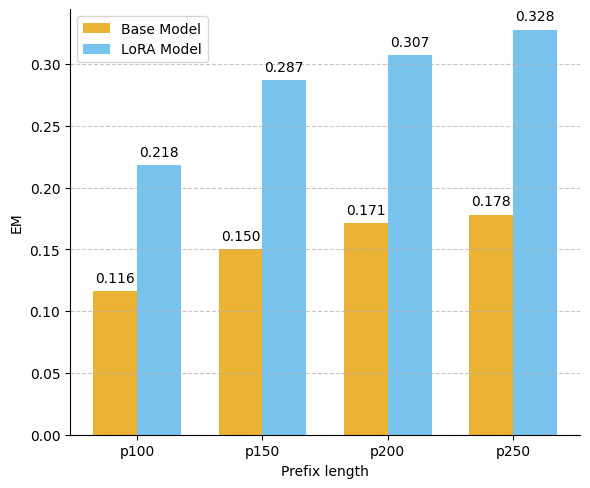

In [17]:
from matplotlib.lines import Line2D
from cycler import cycler

import matplotlib.pyplot as plt
import numpy as np

# Set up the plot
fig, ax = plt.subplots(figsize=(6, 5))
plens = ['p100', 'p150', 'p200', 'p250']

# EM data for both models
base_em = [base_means.loc[pl, 'em'] for pl in plens]
lo_em = [lo_means.loc[pl, 'em'] for pl in plens]  

# Bar positions and width
x_pos = np.arange(len(plens))
bar_width = 0.35

# Plot base model EM
base_bars = ax.bar(x_pos - bar_width/2, base_em, bar_width, 
                   label='Base Model', color='#E69F00', alpha=0.8)

# Plot LoRA model EM (starting from ep1)
lo_bars = ax.bar(x_pos + bar_width/2, lo_em, bar_width, 
                 label='LoRA Model', color='#56B4E9', alpha=0.8)

# Customize the plot
ax.set_xlabel('Prefix length')
ax.set_ylabel('EM')
# ax.set_title('Exact Match Performance: Base vs LoRA Model')
ax.set_xticks(x_pos)
ax.set_xticklabels(plens)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bars in [base_bars, lo_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hide all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

fig.savefig('./lo_plen_forg_ep.pdf', format='pdf')
